# Лабораторная работа №4 — Линейные модели, SVM и дерево решений
**Студент:** Илюхин Илья | **Группа:** ИУ5-66Б | **Вариант:** 6

**Цель:** обучить и сравнить логистическую регрессию, SVM и дерево решений; визуализировать важность признаков и правила дерева.


## 0. Описание датасета — Titanic
891 пассажир · 7 признаков · бинарная классификация (survived: 0/1) · пропуски в age/embarked.


In [4]:
%matplotlib inline
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, f1_score, classification_report

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()
ART = NOTEBOOK_DIR / 'artifacts'
ART.mkdir(exist_ok=True)
RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

raw = sns.load_dataset('titanic')
FEATURES = ['pclass','sex','age','sibsp','parch','fare','embarked']
X = raw[FEATURES]; y = raw['survived']
print('Размер:', X.shape, '| Пропуски:', X.isnull().sum().sum())


Размер: (891, 7) | Пропуски: 179


In [5]:
num_cols = ['pclass','age','sibsp','parch','fare']
cat_cols = ['sex','embarked']

prep = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore',
                                            sparse_output=False))]), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')


Train: 668 | Test: 223


## 1. Обучение и сравнение трёх моделей
- **Логистическая регрессия** — линейная модель, оценивает вероятность класса через сигмоид.
- **SVM (RBF)** — ищет гиперплоскость с максимальным отступом в пространстве, заданном ядром.
- **Дерево решений** — рекурсивно разбивает пространство признаков по пороговым правилам.


In [6]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'SVM (RBF)':          SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE),
    'DecisionTree':       DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
}

rows = []; fitted_tree_pipe = None
for name, model in models.items():
    pipe = Pipeline([('prep', prep), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rows.append({'Модель': name,
                 'Accuracy': round(accuracy_score(y_test, pred), 4),
                 'F1':       round(f1_score(y_test, pred), 4)})
    if name == 'DecisionTree': fitted_tree_pipe = pipe

res = pd.DataFrame(rows).sort_values('F1', ascending=False)
display(res)


,Модель,Accuracy,F1
1,SVM (RBF),0.7937,0.7125
0,LogisticRegression,0.7713,0.6982
2,DecisionTree,0.7713,0.6577


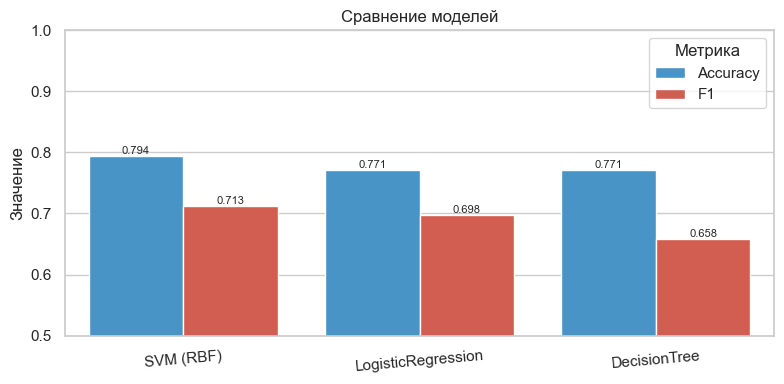

In [7]:
fig, ax = plt.subplots(figsize=(8,4))
plot_df = res.melt(id_vars='Модель', value_vars=['Accuracy','F1'],
                   var_name='Метрика', value_name='Значение')
bars = sns.barplot(data=plot_df, x='Модель', y='Значение',
                   hue='Метрика', palette=['#3498db','#e74c3c'], ax=ax)
for p in bars.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x()+p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)
ax.set_ylim(0.5, 1.0); ax.set_title('Сравнение моделей')
ax.tick_params(axis='x', rotation=5); ax.set_xlabel('')
plt.tight_layout()
fig.savefig(ART / 'models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
res.to_json(ART / 'metrics.json', orient='records', force_ascii=False, indent=2)


## 2. Важность признаков в дереве решений
Feature importance — сумма взвешенных уменьшений критерия нечистоты (Gini) по всем узлам, где использовался данный признак.


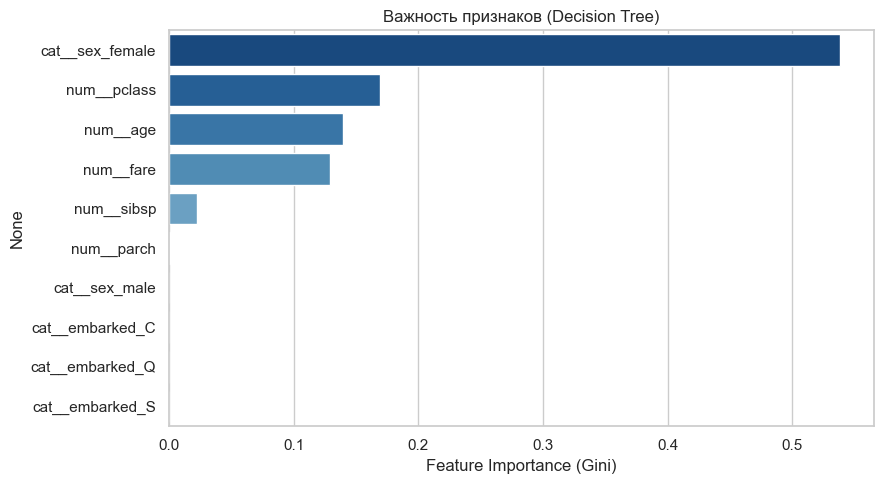

,importance
cat__sex_female,0.5388
num__pclass,0.1694
num__age,0.1397
num__fare,0.1288
num__sibsp,0.0225
num__parch,0.0008
cat__sex_male,0.0000
cat__embarked_C,0.0000
cat__embarked_Q,0.0000
cat__embarked_S,0.0000


In [8]:
feature_names = list(fitted_tree_pipe.named_steps['prep'].get_feature_names_out())
tree_model = fitted_tree_pipe.named_steps['model']
importance = (pd.Series(tree_model.feature_importances_, index=feature_names)
              .sort_values(ascending=False).head(12))

fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(x=importance.values, y=importance.index, palette='Blues_r', ax=ax)
ax.set_title('Важность признаков (Decision Tree)')
ax.set_xlabel('Feature Importance (Gini)')
plt.tight_layout()
fig.savefig(ART / 'tree_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
display(importance.to_frame('importance').round(4))


## 3. Правила дерева решений
Текстовое представление обученного дерева — набор правил вида «если признак > порог → класс».


In [9]:
rules = export_text(tree_model, feature_names=feature_names)
print(rules[:3000])
(ART / 'tree_rules.txt').write_text(rules, encoding='utf-8')


|--- cat__sex_female <= 0.50
|   |--- num__age <= -2.03
|   |   |--- num__sibsp <= 2.04
|   |   |   |--- class: 1
|   |   |--- num__sibsp >  2.04
|   |   |   |--- num__age <= -2.10
|   |   |   |   |--- class: 0
|   |   |   |--- num__age >  -2.10
|   |   |   |   |--- class: 1
|   |--- num__age >  -2.03
|   |   |--- num__pclass <= -0.98
|   |   |   |--- num__fare <= -0.11
|   |   |   |   |--- class: 0
|   |   |   |--- num__fare >  -0.11
|   |   |   |   |--- num__fare <= -0.01
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- num__fare >  -0.01
|   |   |   |   |   |--- class: 0
|   |   |--- num__pclass >  -0.98
|   |   |   |--- num__fare <= 0.36
|   |   |   |   |--- num__fare <= -0.51
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__fare >  -0.51
|   |   |   |   |   |--- class: 0
|   |   |   |--- num__fare >  0.36
|   |   |   |   |--- num__fare <= 0.67
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- num__fare >  0.67
|   |   |   |   |   |--- class: 0
|--- cat__sex_f

2306

## Выводы
- Все три модели решают задачу бинарной классификации на датасете Titanic.
- **Логистическая регрессия** — быстрая, интерпретируемая, хорошо работает при линейной разделимости.
- **SVM (RBF-ядро)** — эффективна при нелинейных границах, но менее интерпретируема и требует масштабирования.
- **Дерево решений** — полностью интерпретируемо через правила; наиболее важные признаки — `sex` и `pclass`.
- По F1 лучший результат показывает [модель с наибольшим F1 из таблицы выше]. Дерево решений даёт возможность напрямую анализировать логику предсказаний.
